In [31]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import re
from scipy.stats import percentileofscore

# Generate dataframe of simulated maps' information

## Create primary dataframe with district boundaries, compactness scores, and populations

In [32]:
#print all csv files from the allocation_by_district folder
#note: not in order!
seeds_by_district_csv_files=glob.glob('./allocation_by_district/*.csv')
# seeds_by_district_csv_files

#alt method for printing all the files...
# for files in glob.glob("./allocation_by_district/*.csv"):
#     print(files) 

#this will get an unsorted list of seeds for all files in ./allocation_by_district folder
district_seeds_list=[]
for fname in seeds_by_district_csv_files:
    res = re.findall("seed_(\d+)_by_district.csv", fname)
    if not res: continue
    district_seeds_list.append(res[0]) # You can append the result to a list

In [33]:
district_seeds_list_sorted=sorted(district_seeds_list)

In [34]:
# path is a string for the path of the folder we want to check
# path = os.getcwd() + '/allocation_by_county'
path = os.getcwd() + '/allocation_by_district'

#list of all filenames in the path which end in .csv
csv_files = glob.glob(os.path.join(path, "*.csv")) 
num_files = len(csv_files) #count of all files

# file_name = './allocation_by_county/seed_{}_by_county.csv'
file_name = './allocation_by_district/seed_{}_by_district.csv'
df_list = []

# This previously worked when all seeds were saved regardless of criteria being met
# for i in range(num_files):
#    iter_number=str(i).rjust(3,'0')
#    df_list.append(pd.read_csv(file_name.format(iter_number)))

for seed in district_seeds_list_sorted:
    df_list.append(pd.read_csv(file_name.format(seed)))


In [35]:
# df=pd.read_csv('./allocation_by_district/seed_005_by_district.csv')
# df.head()

In [36]:
full_nestedlist=[]
for j in range(num_files):
    temp_df = df_list[j]
    list_for_j=[district_seeds_list_sorted[j] 
                # ,temp_df.loc[0,'Reock']
                # ,temp_df.loc[1,'Reock']
                # ,temp_df.loc[2,'Reock']
                # ,temp_df.loc[3,'Reock']
                ,temp_df['Reock'].min()
                # ,temp_df['Reock'].max()
                ,temp_df['Reock'].mean()
                # ,temp_df.loc[0,'PolsbyPopper']
                # ,temp_df.loc[1,'PolsbyPopper']
                # ,temp_df.loc[2,'PolsbyPopper']
                # ,temp_df.loc[3,'PolsbyPopper']
                ,temp_df['PolsbyPopper'].min()
                # ,temp_df['PolsbyPopper'].max()
                ,temp_df['PolsbyPopper'].mean()
                ,temp_df.loc[0,'geometry']
                ,temp_df.loc[1,'geometry']
                ,temp_df.loc[2,'geometry']
                ,temp_df.loc[3,'geometry']
                ,temp_df.loc[0,'population']
                ,temp_df.loc[1,'population']
                ,temp_df.loc[2,'population']
                ,temp_df.loc[3,'population']
                ,temp_df['population'].min()
                ,temp_df['population'].max()
                ]
    full_nestedlist.append(list_for_j)

# full_nestedlist

In [37]:
column_dict=[
    'seed'
    # ,'Reock_d1'
    # ,'Reock_d2'
    # ,'Reock_d3'
    # ,'Reock_d4'
    ,'Reock_min'
    # ,'Reock_max'
    ,'Reock_mean'
    # ,'PP_d1'
    # ,'PP_d2'
    # ,'PP_d3'
    # ,'PP_d4'
    ,'PP_min'
    # ,'PP_max'
    ,'PP_mean'
    ,'dist1_gpd'
    ,'dist2_gpd'
    ,'dist3_gpd'
    ,'dist4_gpd'
    ,'dist1_pop'
    ,'dist2_pop'
    ,'dist3_pop'
    ,'dist4_pop'
    ,'min_pop'
    ,'max_pop']

In [38]:
all_maps_df = pd.DataFrame(full_nestedlist,columns=column_dict)
all_maps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   seed        234 non-null    object 
 1   Reock_min   234 non-null    float64
 2   Reock_mean  234 non-null    float64
 3   PP_min      234 non-null    float64
 4   PP_mean     234 non-null    float64
 5   dist1_gpd   234 non-null    object 
 6   dist2_gpd   234 non-null    object 
 7   dist3_gpd   234 non-null    object 
 8   dist4_gpd   234 non-null    object 
 9   dist1_pop   234 non-null    int64  
 10  dist2_pop   234 non-null    int64  
 11  dist3_pop   234 non-null    int64  
 12  dist4_pop   234 non-null    int64  
 13  min_pop     234 non-null    int64  
 14  max_pop     234 non-null    int64  
dtypes: float64(4), int64(6), object(5)
memory usage: 27.5+ KB


In [39]:
duplicates=all_maps_df[all_maps_df.duplicated(subset=['Reock_min', 'Reock_mean', 'min_pop', 'max_pop'], keep=False)]
duplicates.sort_values(by=['Reock_min']).head()

,seed,Reock_min,Reock_mean,PP_min,PP_mean,dist1_gpd,dist2_gpd,dist3_gpd,dist4_gpd,dist1_pop,dist2_pop,dist3_pop,dist4_pop,min_pop,max_pop
114,127,0.322161,0.415539,0.296865,0.342957,"POLYGON ((558373.895623059 4605901.485357738, ...","POLYGON ((420252.0937440044 4712961.129324797,...",POLYGON ((491768.13570150826 4518326.457960803...,"POLYGON ((327366.1385466402 4493729.313993027,...",803655,791149,793091,802474,791149,803655
52,057,0.322161,0.415539,0.296865,0.342957,"POLYGON ((558373.895623059 4605901.485357738, ...","POLYGON ((420252.0937440044 4712961.129324797,...",POLYGON ((491768.13570150826 4518326.457960803...,"POLYGON ((327366.1385466402 4493729.313993027,...",803655,791149,793091,802474,791149,803655
13,016,0.333025,0.428417,0.252851,0.366773,"POLYGON ((325806.6758530381 4617350.978689799,...",POLYGON ((519337.18424878584 4654016.738651686...,"POLYGON ((327366.1385466402 4493729.313993027,...","POLYGON ((452965.6966743361 4501971.787843896,...",791221,798070,804149,796929,791221,804149
89,100,0.333025,0.428417,0.252851,0.366773,"POLYGON ((452965.6966743361 4501971.787843896,...","POLYGON ((327366.1385466402 4493729.313993027,...","POLYGON ((325806.6758530381 4617350.978689799,...",POLYGON ((519337.18424878584 4654016.738651686...,796929,804149,791221,798070,791221,804149
183,202,0.378544,0.468410,0.306080,0.410408,POLYGON ((605837.8838751405 4635240.0353934495...,"POLYGON ((452965.6966743361 4501971.787843896,...","POLYGON ((462236.7901034034 4595237.549011647,...","POLYGON ((298962.9316855775 4494915.943961601,...",790727,797405,803846,798391,790727,803846


In [40]:
all_maps_sans_duplicates=all_maps_df.drop_duplicates(subset=['Reock_min', 'Reock_mean', 'min_pop', 'max_pop'], keep='first')
len(all_maps_sans_duplicates)

215

## Create compactness dataframe

In [41]:
column_dict_compactness_analysis=[
    'seed',
    'Reock_min',
    # 'Reock_max',
    'Reock_mean',
    'PP_min',
    # 'PP_max',
    'PP_mean',
    'min_pop',
    'max_pop']

In [42]:
compactness_analysis_df = all_maps_sans_duplicates[column_dict_compactness_analysis]
compactness_analysis_df

#show all rows instead of first 5/last 5
# pd.set_option('display.max_rows', None)
# compactness_analysis_df

#reset max_rows:
# pd.reset_option(“max_rows”)

,seed,Reock_min,Reock_mean,PP_min,PP_mean,min_pop,max_pop
0,000,0.332951,0.367877,0.235157,0.302992,790938,804784
1,001,0.448682,0.508731,0.338438,0.435282,791513,802747
2,003,0.428981,0.490348,0.294441,0.339815,791071,804852
3,004,0.342567,0.388122,0.288226,0.358882,795671,800138
4,005,0.460231,0.512357,0.411954,0.454914,795792,798933
...,...,...,...,...,...,...,...
228,252,0.360830,0.474449,0.230766,0.354070,794348,800400
229,253,0.186280,0.279657,0.144578,0.230056,790611,803955
230,255,0.368182,0.410223,0.305965,0.366372,793309,799976
232,257,0.347251,0.416687,0.330434,0.367020,793050,803696


In [43]:
# Export to csv 
compactness_analysis_df.to_csv('./data/compactness_scores_simulations.csv', index=False, header=True)

# Compare simulated maps with enacted and alternate maps

## Prep dataframes with enacted and alternate map data

In [44]:
enacted_map=pd.read_csv('enacted_map.csv')
enacted_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((597046.3063824802 4495965.241673183,...",797584,655223.617473,4.626175e+06,1,2.847289e+10,1.120709e+06,0.284876,160047.768111,0.353820
1,"POLYGON ((558251.4820985557 4634182.10198691, ...",797589,631594.469070,4.793646e+06,2,3.361224e+10,1.004718e+06,0.418426,141576.968905,0.533780
2,POLYGON ((413996.78923838487 4491953.713269984...,797551,376909.476792,4.576509e+06,3,2.782373e+10,9.971415e+05,0.351651,144824.951242,0.422259
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797645,341387.505752,4.616499e+06,4,5.578923e+10,1.595846e+06,0.275282,191597.504183,0.483750


In [45]:
alternate_map=pd.read_csv('alt_map.csv')
alternate_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((659405.8034389731 4506627.439222173,...",797655,655223.617473,4.626175e+06,1,1.669426e+10,8.095316e+05,0.320118,116372.651805,0.392388
1,"POLYGON ((568721.6887085006 4527942.280230374,...",797556,631594.469070,4.793646e+06,2,4.045878e+10,1.265121e+06,0.317657,155907.333430,0.529822
2,POLYGON ((452694.19555372297 4492297.318383798...,797584,357154.753953,4.543364e+06,3,2.260122e+10,8.294785e+05,0.412792,136323.573265,0.387115
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797574,376909.476792,4.576509e+06,4,6.594382e+10,1.557147e+06,0.341763,226406.411288,0.409493


In [46]:
map_dict = { 'measure': ['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']
            , 'enacted': [enacted_map['Reock'].min(),enacted_map['Reock'].mean(),enacted_map['PolsbyPopper'].min(),enacted_map['PolsbyPopper'].mean()]
            , 'alternate': [alternate_map['Reock'].min(),alternate_map['Reock'].mean(), alternate_map['PolsbyPopper'].min(),alternate_map['PolsbyPopper'].mean() ]}

In [47]:
maps_df=pd.DataFrame(map_dict)
maps_df

,measure,enacted,alternate
0,Reock_min,0.353820,0.387115
1,Reock_mean,0.448402,0.429705
2,PP_min,0.275282,0.317657
3,PP_mean,0.332559,0.348082


## Create compactness graphs

In [48]:
compactness_analysis_df[['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']]

,Reock_min,Reock_mean,PP_min,PP_mean
0,0.332951,0.367877,0.235157,0.302992
1,0.448682,0.508731,0.338438,0.435282
2,0.428981,0.490348,0.294441,0.339815
3,0.342567,0.388122,0.288226,0.358882
4,0.460231,0.512357,0.411954,0.454914
...,...,...,...,...
228,0.360830,0.474449,0.230766,0.354070
229,0.186280,0.279657,0.144578,0.230056
230,0.368182,0.410223,0.305965,0.366372
232,0.347251,0.416687,0.330434,0.367020


In [49]:
#unstack compactness_analysis_df to prep for compactness score graphic
compactness_df=compactness_analysis_df[['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']].unstack().reset_index(drop=False)
compactness_df=compactness_df.drop(columns=['level_1'])
compactness_df=compactness_df.rename(columns={"level_0": "Metric", 0:"compactness_score"})
compactness_df

,Metric,compactness_score
0,Reock_min,0.332951
1,Reock_min,0.448682
2,Reock_min,0.428981
3,Reock_min,0.342567
4,Reock_min,0.460231
...,...,...
855,PP_mean,0.354070
856,PP_mean,0.230056
857,PP_mean,0.366372
858,PP_mean,0.367020


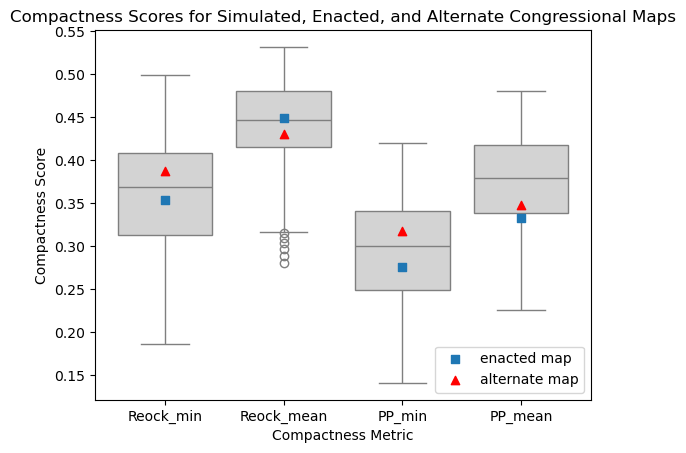

In [50]:
x = maps_df['measure']
y = maps_df['enacted']
b = maps_df['alternate']

X=compactness_df['Metric']
Y=compactness_df['compactness_score']


# plt.scatter(X, Y, alpha=.1, color='lightgray', zorder=1, label='simulated')

# compactness_analysis_df.boxplot(column=['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean'], rot=30, zorder=1, positions=range(4))
sns.boxplot(x=X, y=Y,color='lightgray', zorder=1)
plt.scatter(x=x, y=y,marker=',', label='enacted map', zorder=2)
plt.scatter(x=x, y=b, marker='^', color='red',label='alternate map', zorder=3)
plt.xlabel('Compactness Metric')
plt.ylabel('Compactness Score')
plt.title('Compactness Scores for Simulated, Enacted, and Alternate Congressional Maps')
plt.legend(loc='lower right')
# maps_df.plot.scatter(x='measure', y='enacted', zorder=2)
plt.show()
plt.savefig('./images_for_paper/compactness_scores.png')
# maps_df.plot.scatter(column=['Reock_min', 'Reock_mean', 'PP_mean', 'PP_min'], zorder=2)

Regarding above boxplots, the enacted map is at or below the median for all metrics. The least compact alternate map district is more optimally compact than the least compact enacted district. Additionally, the least compact alternate district is above the median for both metrics. 

In [51]:
# Juxtaposed boxplot and scatterplot with Reock minimum only 
# reock_min=maps_df.loc[maps_df['measure']=='Reock_min'][['enacted', 'alternate']]
# plt.boxplot(x=compactness_analysis_df['Reock_min'], zorder=1)
# plt.scatter(x=[1,1], y=reock_min, zorder=2)
# plt.show()


## Computing percentiles of enacted and alternate maps

In [52]:
reock_min_summary=list(compactness_analysis_df['Reock_min'].describe())[1:]
reock_min_summary.pop(1)
reock_mean_summary=list(compactness_analysis_df['Reock_mean'].describe())[1:]
reock_mean_summary.pop(1)
PP_min_summary=list(compactness_analysis_df['PP_min'].describe())[1:]
PP_min_summary.pop(1)
PP_mean_summary=list(compactness_analysis_df['PP_mean'].describe())[1:]
PP_mean_summary.pop(1)

0.05420502080501339

In [53]:
summary_dict= { 'Statistic': ['Mean', 'Minimum', 'Quartile 1', 'Median', 'Quartile 3', 'Maximum']
               ,'Reock Min': reock_min_summary
               ,'Reock Mean': reock_mean_summary
               ,'Polsby-Popper Min': PP_min_summary
               ,'Polsby-Popper Mean': PP_mean_summary
}

compactness_stats=pd.DataFrame(summary_dict)
compactness_stats

,Statistic,Reock Min,Reock Mean,Polsby-Popper Min,Polsby-Popper Mean
0,Mean,0.358392,0.441262,0.294897,0.376147
1,Minimum,0.186280,0.279657,0.141041,0.225026
2,Quartile 1,0.312704,0.414681,0.248336,0.338172
3,Median,0.368119,0.445834,0.300280,0.378956
4,Quartile 3,0.408551,0.480513,0.340770,0.417003
5,Maximum,0.498430,0.531432,0.419491,0.480584


In [54]:
compactness_stats.to_excel('./data/compactness_stats.xlsx',index=False, header=True)

In [55]:
reock_min_array=compactness_analysis_df['Reock_min'].to_numpy()
reock_mean_array=compactness_analysis_df['Reock_mean'].to_numpy()
pp_min_array=compactness_analysis_df['PP_min'].to_numpy()
pp_mean_array=compactness_analysis_df['PP_mean'].to_numpy()

In [56]:
percentile_dict = { 'measure': ['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']
            , 'enacted': [percentileofscore(reock_min_array, maps_df.iloc[0]['enacted'])
                          ,percentileofscore(reock_mean_array, maps_df.iloc[1]['enacted'])
                          ,percentileofscore(pp_min_array, maps_df.iloc[2]['enacted'])
                          ,percentileofscore(pp_mean_array, maps_df.iloc[3]['enacted'])]
            , 'alternate': [percentileofscore(reock_min_array, maps_df.iloc[0]['alternate'])
                            ,percentileofscore(reock_mean_array, maps_df.iloc[1]['alternate'])
                            ,percentileofscore(pp_min_array, maps_df.iloc[2]['alternate'])
                            ,percentileofscore(pp_mean_array, maps_df.iloc[3]['alternate'])]
                }

In [57]:
percentile_df=pd.DataFrame(percentile_dict)
percentile_df

,measure,enacted,alternate
0,Reock_min,43.720930,64.651163
1,Reock_mean,51.627907,35.813953
2,PP_min,33.023256,60.465116
3,PP_mean,20.465116,31.162791


## Calculating population deviation for enacted and alternate maps

In [58]:
ideal_population=797592.25

In [59]:
(((enacted_map['population']-ideal_population).abs())/ideal_population)*100

0    0.001034
1    0.000407
2    0.005172
3    0.006614
Name: population, dtype: float64

In [60]:
(((alternate_map['population']-ideal_population).abs())/ideal_population)*100

0    0.007867
1    0.004545
2    0.001034
3    0.002288
Name: population, dtype: float64

In [61]:
print('mean population deviation for enacted map is', ((((enacted_map['population']-ideal_population).abs())/ideal_population).mean())*100)
print('mean population deviation for the alternate map is', ((((alternate_map['population']-ideal_population).abs())/ideal_population).mean())*100)

mean population deviation for enacted map is 0.003306827517443907
mean population deviation for the alternate map is 0.003933714250608628


### Removing simulated maps that don't fall in 1% deviation (relevant for 7/31/25 to prep Iowa_districtgenerator to rerun seeds)

In [ ]:
min_district=ideal_population*.99
max_district=ideal_population*1.01
print(min_district, max_district)

In [ ]:
maps_within_pop_range=compactness_data_df.loc[(compactness_data_df['min_pop']>min_district) & (compactness_data_df['max_pop']<max_district)]['seed'].tolist()

In [ ]:
maps_within_pop_range
maps_within_pop_range_list=[]
for number in maps_within_pop_range:
    maps_within_pop_range_list.append(str(number).rjust(3, '0'))

In [ ]:
seeds=list(range(260))
seeds_list = []
for seed_number in seeds:
    seeds_list.append(str(seed_number).rjust(3, '0'))

In [ ]:
seeds_to_rerun = [seed for seed in seeds_list if seed not in maps_within_pop_range_list]
# =seeds_list.remove(maps_within_pop_range_list)
len(seeds_to_rerun)

In [ ]:
file_name = './allocation_by_district/seed_{}_by_district.csv'

for iter_number in seeds_to_rerun:
#    iter_number=str(i).rjust(3,'0')
    os.remove(file_name.format(iter_number))
#    df_list.append(pd.read_csv(file_name.format(iter_number)))

In [ ]:
file_name_county = './allocation_by_county/seed_{}_by_county.csv'
for iter_number in seeds_to_rerun:
    os.remove(file_name_county.format(iter_number))


In [ ]:
file_name_distmap = './district_maps/seed_{}_district_map.png'
for iter_number in seeds_to_rerun:
    os.remove(file_name_distmap.format(iter_number))

In [ ]:
seeds_to_rerun_ints = [seed for seed in seeds if seed not in maps_within_pop_range]
# seeds_to_rerun_ints

## Graphing populations for all maps

In [62]:
map_pop_dict = { 'measure': ['min_pop', 'max_pop']
            , 'enacted': [enacted_map['population'].min(),enacted_map['population'].max()]
            , 'alternate': [alternate_map['population'].min(),alternate_map['population'].max()]}
map_pops=pd.DataFrame(map_pop_dict)
map_pops

,measure,enacted,alternate
0,min_pop,797551,797556
1,max_pop,797645,797655


In [29]:
#unstack compactness_analysis_df to prep for district population graphics
dist_pop_df=compactness_analysis_df[['min_pop', 'max_pop']].unstack().reset_index(drop=False)
dist_pop_df=dist_pop_df.drop(columns=['level_1'])
dist_pop_df=dist_pop_df.rename(columns={"level_0": "min_max", 0:"population"})
dist_pop_df

,min_max,population
0,min_pop,790938
1,min_pop,791513
2,min_pop,791071
3,min_pop,795671
4,min_pop,795792
...,...,...
425,max_pop,800400
426,max_pop,803955
427,max_pop,799976
428,max_pop,803696


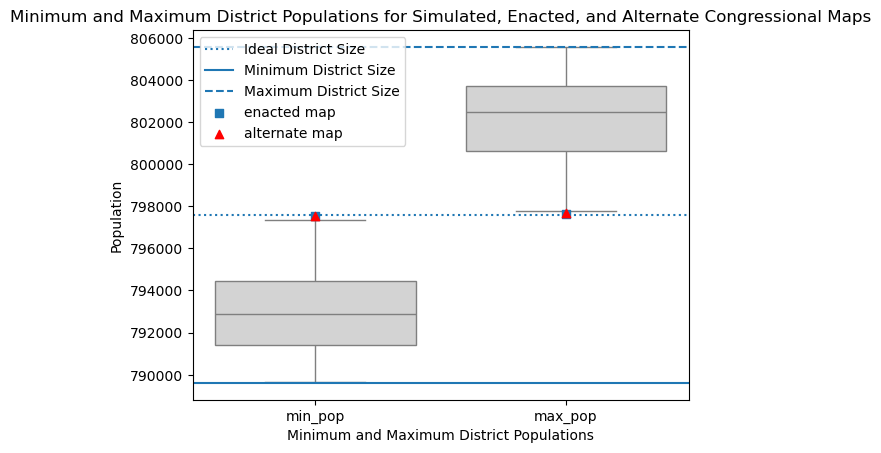

In [64]:
pops = map_pops['measure']
enacted_pops = map_pops['enacted']
alt_pops = map_pops['alternate']
min_district=ideal_population*.99
max_district=ideal_population*1.01

simulated_pop_metric =dist_pop_df['min_max']
simulated_dist_populations = dist_pop_df['population']

sns.boxplot(x=simulated_pop_metric, y=simulated_dist_populations,color='lightgray',  zorder=1)

# compactness_analysis_df.boxplot(column=['min_pop', 'max_pop'], rot=30, zorder=1, positions=range(2))
plt.axhline(ideal_population, linestyle='dotted', label='Ideal District Size')
plt.axhline(min_district, label='Minimum District Size', linestyle='solid')
plt.axhline(max_district, label='Maximum District Size', linestyle='--')
plt.scatter(x=pops, y=enacted_pops, marker=',', label='enacted map', zorder=2)
plt.scatter(x=pops, y=alt_pops, marker='^', color='red', label='alternate map', zorder=3)
plt.xlabel('Minimum and Maximum District Populations')
plt.ylabel('Population')
plt.title('Minimum and Maximum District Populations for Simulated, Enacted, and Alternate Congressional Maps')
plt.legend(loc='upper left')
plt.savefig('./images_for_paper/min_max_dist_pops.png')
# maps_df.plot.scatter(x='measure', y='enacted', zorder=2)
plt.show()